# Synthetic Assessment Data Pipeline (SAD-Pipe) - Simulation

This notebook generates a synthetic multiple-choice exam dataset with realistic psychometric structure.

## Purpose

The goal is to produce *reproducible* synthetic response data for prototyping and testing downstream analysis workflows (e.g., scoring, item analysis, distractor behavior).

The simulation combines:

- 2PL-like knowledge model (item difficulty `b`, discrimination `a`)
- person-level traits (`theta_true`, `carelessness`, `guessiness`, `testwiseness`)
- item types (regular / regular_clean / diluted / misleading)
- distractor attractiveness profiles

## Reproducibility

- Randomness is controlled via `seed` (NumPy `default_rng`).
- With the same `seed` and the same `SimulationConfig`, the notebook is intended to generate identical outputs.

## Configuration

The main entry point is:

- `results = run_simulation(config)`

Key parameters:

- `seed`: controls randomness
- `n_items`: number of items
- `n_students`: number of test-takers
- `options`: answer options (default: `A`–`E`)
- `item_type_dist`: item type proportions

### Item type proportions

Set proportions via `item_type_dist` in `SimulationConfig`. You can omit `regular`; it will be set to the remainder.

```python
config = SimulationConfig(
    seed=63111426,
    n_items=80,
    n_students=200,
    item_type_dist={
        "regular_clean": 0.10, # 10% of the items
        "diluted": 0.20, # 20 % of the items
        "misleading": 0.15, # 15 % of the items
        # "regular" becomes 0.55 automatically
    },
)
results = run_simulation(config)
```

## Outputs (data dictionary)

The simulation returns a dictionary `results` with four pandas DataFrames.

### `results["answer_matrix"]`

- **Shape**: `(n_students, n_items)`
- **Rows**: one row per person
- **Columns**: `item1 ... itemN`
- **Values**: selected option label (e.g., `"A"`, `"B"`, ...)

### `results["scored_responses"]`

- **Item columns**: `0/1` correctness per item
- **`score`**: sum over item columns
- **`score_pct`**: `score / n_items * 100`

### `results["item_metadata"]`

One row per item.

- **`item`**: item identifier (e.g., `item17`)
- **`item_type`**: one of `regular`, `regular_clean`, `diluted`, `misleading`
- **`num_options`**: number of answer options (including the correct answer)
- **`correct_answer`**: correct option label
- **`a_param`**: discrimination
- **`b_param`**: difficulty
- **`slip`**: slip probability (know → incorrect)
- **`distractors`**: list of incorrect option labels
- **`distractor_weights`**: mapping distractor → sampling weight

### `results["testtakers"]`

One row per person.

- **`theta_true`**: latent ability
- **`carelessness`**, **`guessiness`**, **`testwiseness`**: behavioral traits
- **`score`**, **`score_pct`**: total performance summary

In [1]:
# Standard library imports
from __future__ import annotations
import os
from pathlib import Path
from typing import Dict, List, Literal, Optional, Tuple, TypedDict

# Third-party imports
import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skewnorm

In [2]:
# Configure display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)
sns.set_theme(style="whitegrid", palette="pastel")

# Define color palette for item types
item_type_colors = {
    'regular':       '#3B5070',
    'regular_clean': '#765B7A',
    'diluted':       '#B56576',
    'misleading':    '#eaac8b', 
}


In [3]:
class SimulationConfig:
    """Configuration parameters for the simulation."""

    def __init__(
        self,
        seed: int = 63111426,
        n_items: int = 80,
        n_students: int = 200,
        options: List[str] = ["A", "B", "C", "D", "E"],
        output_dir: str = "../data",
        item_type_dist: Optional[Dict[str, float]] = None,
        theta: Optional[np.ndarray] = None 
        
    ):
        self.seed = seed
        self.n_items = n_items
        self.n_students = n_students
        self.options = options
        self.output_dir = Path(output_dir)
        self.theta = theta


        self.item_type_dist = {
            "regular_clean": 0.20,
            "diluted": 0.10,
            "misleading": 0.10,
            "regular": 0.60,
        }

        if item_type_dist is not None:
            self.item_type_dist = dict(item_type_dist)

        self._normalize_and_validate_distribution()

    def _normalize_and_validate_distribution(self) -> None:
        expected = {"regular", "regular_clean", "diluted", "misleading"}
        unknown = set(self.item_type_dist) - expected
        if unknown:
            raise ValueError(f"item_type_dist contains unknown keys: {sorted(unknown)}")
            
        for k, v in self.item_type_dist.items():
            if v < 0:
                raise ValueError(f"item_type_dist contains negative value for {k}: {v}")

        
        total = float(sum(self.item_type_dist.values()))
        if total < 0:
            raise ValueError("item_type_dist must sum to a positive number")

        if total > 1.0 + 1e-9:
            raise ValueError(f"Item type probabilities sum to {total}, expected <= 1.0")

        if "regular" not in self.item_type_dist:
            self.item_type_dist["regular"] = 1.0 - total
            total = 1.0

        if not np.isclose(total, 1.0):
            self.item_type_dist["regular"] = self.item_type_dist.get("regular", 0.0) + (1.0 - total)

        total2 = float(sum(self.item_type_dist.values()))
        if not np.isclose(total2, 1.0):
            raise ValueError(f"Item type probabilities sum to {total2}, expected 1.0")

        self.item_type_dist = {k: float(self.item_type_dist[k]) for k in expected}

In [4]:
class ItemMetadata(TypedDict):
    """Metadata for each test item."""

    item: str
    item_type: Literalb["regular", "regular_clean", "misleading", "diluted"]
    num_options: int
    correct_answer: str
    a_param: float
    b_param: float
    slip: float
    distractors: List[str]
    distractor_weights: Dict[str, float]


class SimulationResults(TypedDict):
    """Container for simulation results."""

    answer_matrix: pd.DataFrame
    item_metadata: pd.DataFrame
    scored_responses: pd.DataFrame
    testtakers: pd.DataFrame

In [5]:
class ItemGenerator:
    """Generate items with realistic psychometric properties."""

    def __init__(self, config: SimulationConfig):
        self.config = config
        self.rng = np.random.default_rng(config.seed)

        # Item parameter specifications for each item type
        self.item_param_specs = {
            # Textbook, well‑behaved items
            "regular_clean": {
                "b_loc": -0.3, #-0.8
                "b_scale": 0.6,
                "a_low": 0.90,
                "a_high": 1.80,
            },
        
            # Realistic but still basically unidimensional
            "regular": {
                "b_loc": -0.7, #-1.1
                "b_scale": 1.2,#0.8   
                "a_low": 0.60,    
                "a_high": 1.70,
            },
        
            # Structurally “soft” items: diluted discrimination + trait interference
            "diluted": {
                "b_loc": -1.1,
                "b_scale": 0.8,  #0.8
                "a_low": 0.20,    
                "a_high": 0.80,   
            },
        
            # Trap items: normal-ish slopes, misfit comes from trap band + distractors
            "misleading": {
                "b_loc": -0.2,    
                "b_scale": 0.9,   
                "a_low": 0.50,    
                "a_high": 1.80,
            },
        }

        # Distractor behavior specifications for each item type
        self.distractor_specs = {
            "regular_clean": {"prob": 0.0, "bump": 0.0, "force_dominant": False},
            "regular": {"prob": 0.3, "bump": 0.15, "force_dominant": False},
            "diluted": {"prob": 0.7, "bump": 0.30, "force_dominant": False},
            "misleading": {"prob": 0.95, "bump": 0.60, "force_dominant": True},
        }


    # Assign item types using the Largest Remainder Method
    # Ensures the total number of items equals n_items exactly
    def _assign_item_types(self) -> List[str]:
        n = int(self.config.n_items)
        keys = ["regular_clean", "diluted", "misleading", "regular"]

        # 1. Compute expected counts (real-valued)
        raw = {k: self.config.item_type_dist[k] * n for k in keys}

        # 2. Take the floor of each expected count
        base = {k: int(np.floor(raw[k])) for k in keys}

        # 3. Distribute remaining items based on largest fractional parts
        remainder = n - sum(base.values())
        if remainder > 0:
            # Sort by descending fractional remainder
            diffs = sorted(
                ((raw[k] - base[k], k) for k in keys),
                reverse=True
            )
            for _, k in diffs[:remainder]:
                base[k] += 1

        # 4. Expand into a list of item types
        item_types: List[str] = []
        for k in keys:
            item_types.extend([k] * base[k])

        # 5. Shuffle for random ordering
        self.rng.shuffle(item_types)

        return item_types

    # Main item generation loop
    def generate_items(self) -> Tuple[List[ItemMetadata], Dict[str, str]]:
        items = []
        answer_key = {}

        item_types = self._assign_item_types()

        for i, item_type in enumerate(item_types, 1):
            item_id = f"item{i}"
            item, correct = self._generate_item(item_id, item_type)
            items.append(item)
            answer_key[item_id] = correct

        return items, answer_key


    # Generate a single item with parameters and distractors
    def _generate_item(self, item_id: str, item_type: str) -> Tuple[ItemMetadata, str]:
        # Randomly choose number of options
        num_options = int(self.rng.choice([3, 4, 5], p=[0.25, 0.45, 0.30]))
        options = self.config.options[:num_options]

        # Choose correct answer
        correct = str(self.rng.choice(options))
        distractors = [o for o in options if o != correct]

        # Draw IRT parameters
        spec = self.item_param_specs[item_type]
        b = self.rng.normal(spec["b_loc"], spec["b_scale"])
        a = self.rng.uniform(spec["a_low"], spec["a_high"])

        # Slip parameter
        slip = self.rng.beta(1.5, 30)

        # Distractor weights
        distractor_weights = self._generate_distractor_weights(distractors, item_type)

        # Construct item metadata
        item: ItemMetadata = {
            "item": item_id,
            "item_type": item_type,
            "num_options": num_options,
            "correct_answer": correct,
            "a_param": float(a),
            "b_param": float(b),
            "slip": float(slip),
            "distractors": distractors,
            "distractor_weights": distractor_weights,
        }

        return item, correct


    # Generate distractor weights with optional bumps
    def _generate_distractor_weights(self, distractors: List[str], item_type: str) -> Dict[str, float]:
        k = len(distractors)
        if k == 0:
            return {}

        # Base weight patterns depending on number of distractors
        if k == 1:
            base_weights = np.array([1.0])
        elif k == 2:
            base_weights = np.array([0.6, 0.4])
        else:
            dominant = 0.45
            medium = 0.30
            weak = (1.0 - dominant - medium) / (k - 2)
            base_weights = np.array([dominant, medium] + [weak] * (k - 2))
            base_weights = base_weights / base_weights.sum()

        # Apply distractor bump logic
        spec = self.distractor_specs[item_type]
        if self.rng.random() < spec["prob"] and k > 1:
            idx = int(self.rng.integers(0, k))
            base_weights[idx] += spec["bump"]
            base_weights = base_weights / base_weights.sum()

            # Enforce a dominant distractor if required
            if spec["force_dominant"]:
                dominant_idx = int(np.argmax(base_weights))
                base_weights[dominant_idx] = max(base_weights[dominant_idx], 0.6)
                base_weights = base_weights / base_weights.sum()

        return dict(zip(distractors, base_weights))

In [6]:
class ResponseSimulator:
    """Simulate test-taker responses to items."""
    
    def __init__(self, config: SimulationConfig):
        self.config = config
        self.rng = np.random.default_rng(config.seed)
    
    def simulate_responses(
        self,
        items: List[ItemMetadata],
        n_students: int
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """Simulate responses for all students and items."""
        # Generate student abilities and traits
        theta, traits = self._generate_student_abilities(n_students)
        
        # Initialize response matrices
        n_items = len(items)
        answer_matrix = pd.DataFrame(index=range(n_students))
        scored_responses = pd.DataFrame(index=range(n_students))
        
        # Simulate responses for each item
        for item in items:
            item_id = item["item"]
            responses = self._simulate_item_responses(item, theta, traits)
            
            # Store responses
            answer_matrix[item_id] = responses["answers"]
            scored_responses[item_id] = responses["scores"]
        
        # Calculate total scores
        scored_responses["score"] = scored_responses.sum(axis=1)
        scored_responses["score_pct"] = (scored_responses["score"] / n_items * 100).round(2)
        
        # Combine traits with scores
        traits_df = pd.DataFrame({
            "theta_true": theta,
            **{k: v for k, v in traits.items()}
        })
        testtakers = pd.concat([traits_df, scored_responses[["score", "score_pct"]]], axis=1)
        
        return answer_matrix, scored_responses, testtakers

    def _generate_student_abilities(self, n_students: int) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        """Generate student abilities and behavioral traits."""
        # If user provided custom theta, use it
        if self.config.theta is not None:
            theta = np.asarray(self.config.theta)
            if len(theta) != n_students:
                raise ValueError("Provided theta array must match n_students.")
        else:
            # Default behavior: generate theta internally
            theta_main = self.rng.beta(8, 2, size=n_students) * 6 - 4
            theta_elite = self.rng.normal(loc=2.6, scale=0.4, size=n_students)
            mix = self.rng.random(size=n_students) < 0.03
            theta = np.where(mix, theta_elite, theta_main)

                
        # Identify top performers (top 12%)
        top_mask = theta > np.quantile(theta, 0.88)
        
        # Generate behavioral traits
        traits = {
           # Carelessness: small, symmetric noise (neutral predictor)
            "carelessness": np.clip(self.rng.beta(2, 12, size=n_students) * 0.10, 0.0, 0.08),
       
            # Guessiness: moderate, stable upward bias
            "guessiness": np.clip(self.rng.beta(2, 9, size=n_students) * 0.40, 0.00, 0.28),
        
            # Baseline testwiseness before ability modulation
            "testwiseness": self.rng.normal(loc=-0.20, scale=0.20, size=n_students)
        }

        # Ability‑dependent testwiseness
        # Base draw
        base_tw = self.rng.normal(loc=0.10, scale=0.20, size=n_students)
        
        # Severity increases the lower theta is below 1
        severity = np.clip(1.0 - theta, 0.0, None)
        
        # Normalize severity so max = 1 (but keep some variance for high theta)
        if severity.max() > 0:
            severity = 0.7 * (severity / severity.max()) + 0.3
        
        # Final testwiseness
        traits["testwiseness"] = base_tw - severity
        
        # Adjust traits for top performers
        traits["carelessness"][top_mask] *= 0.85
       # traits["guessiness"][top_mask]   *= 0.85

        
        return theta, traits

    def _simulate_item_responses(
        self,
        item: ItemMetadata,
        theta: np.ndarray,
        traits: Dict[str, np.ndarray]
    ) -> Dict[str, np.ndarray]:
    
        n_students = len(theta)
        a = item["a_param"]
        b = item["b_param"]
        slip = item["slip"]
        correct = item["correct_answer"]
        distractors = item["distractors"].copy()
        distractor_weights = item["distractor_weights"].copy()
    
        answers = np.empty(n_students, dtype=object)
        scores = np.zeros(n_students)
    
        # Base 2PL knowledge probability
        p_know = 1 / (1 + np.exp(-a * (theta - b)))
        p_know = np.clip(p_know + self.rng.normal(0, 0.05, size=n_students), 0, 1)
    
        # Misleading items: keep your noise, but add trap band later
        if item["item_type"] == "misleading":
            theta_adj = theta + self.rng.normal(0, 0.4, size=n_students)
            p_know = 1 / (1 + np.exp(-a * (theta_adj - b)))
    
        # Identify dominant distractor once
        if distractor_weights:
            dominant_distractor = max(distractor_weights, key=distractor_weights.get)
        else:
            dominant_distractor = distractors[0] if distractors else None
    
        # Main response loop
        for i in range(n_students):
            knows = self.rng.random() < p_know[i]
    

            # 1. CARELESSNESS (neutral noise)
            if knows and self.rng.random() < traits["carelessness"][i]:
                answers[i] = self._choose_incorrect(correct, distractors, distractor_weights)
                scores[i] = 0
                continue
    

            # 2. MISLEADING ITEM TRAP BAND
            if item["item_type"] == "misleading":
                in_trap_band = theta[i] < -0.5
                if in_trap_band and not knows:
                    if self.rng.random() < 0.85:
                        answers[i] = dominant_distractor
                        scores[i] = 0
                        continue
    

            # 3. KNOWS THE ANSWER
            if knows:
                if self.rng.random() < slip:
                    answers[i] = self._choose_incorrect(correct, distractors, distractor_weights)
                    scores[i] = 0
                else:
                    answers[i] = correct
                    scores[i] = 1
                continue
    
            
            # 4. DOES NOT KNOW THE ANSWER
            # 4a. TESTWISENESS (bad students choose middle option more often)
            if traits["testwiseness"][i] < -0.05 and len(distractors) > 1:
                middle_index = len(distractors) // 2
                middle_option = distractors[middle_index]
                if self.rng.random() < 0.60:
                    answers[i] = middle_option
                    scores[i] = 1 if answers[i] == correct else 0
                    continue
            
            # 4b. GUESSINESS (biased guessing mode)
            if self.rng.random() < traits["guessiness"][i]:
                n_options = len(distractors) + 1
                p_correct = 1.0 / n_options
                if self.rng.random() < p_correct:
                    answers[i] = correct
                else:
                    answers[i] = self.rng.choice(distractors)
                scores[i] = 1 if answers[i] == correct else 0
                continue
            
            # 4c. FINAL FALLBACK — uniform guess
            all_options = [correct] + distractors
            answers[i] = self.rng.choice(all_options)
            scores[i] = 1 if answers[i] == correct else 0
    

        return {"answers": answers, "scores": scores}

    
    def _choose_incorrect(
        self,
        correct: str,
        distractors: List[str],
        distractor_weights: Dict[str, float]
    ) -> str:
        """Choose an incorrect answer based on distractor weights."""
        if not distractors:
            return correct  # Shouldn't happen, but just in case
            
        if not distractor_weights:
            return self.rng.choice(distractors)
            
        return self.rng.choice(
            list(distractor_weights.keys()),
            p=list(distractor_weights.values())
        )

In [7]:
def run_simulation(config: Optional[SimulationConfig] = None) -> SimulationResults:
    """Run the complete simulation pipeline."""
    if config is None:
        config = SimulationConfig()
    
    # Create output directory
    os.makedirs(config.output_dir, exist_ok=True)
    
    # Initialize components
    item_generator = ItemGenerator(config)
    response_simulator = ResponseSimulator(config)
    
    # Generate items and metadata
    print("Generating test items...")
    items, answer_key = item_generator.generate_items()
    item_metadata = pd.DataFrame(items)
    
    # Simulate responses
    print(f"Simulating responses for {config.n_students} students...")
    answer_matrix, scored_responses, testtakers = response_simulator.simulate_responses(
        items, config.n_students
    )
    
    # Prepare results
    results: SimulationResults = {
        "answer_matrix": answer_matrix,
        "item_metadata": item_metadata,
        "scored_responses": scored_responses,
        "testtakers": testtakers
    }
    
    # Save results
    print(f"Saving results to {config.output_dir}...")
    for name, df in results.items():
        df.to_csv(config.output_dir / f"{name}_py.csv", index=False)
        df.to_pickle(config.output_dir / f"{name}.pkl")
    
    return results

## Step 0 — Configure Your Test

In this block you define the structure of the exam itself:
- total number of items,
- proportions of each item type,
- and the remaining proportion will automatically become “regular” items.

Feel free to adjust these values to create easier, harder, or more diagnostic tests.

In [8]:
# --- Test Blueprint Parameters ---

n_items = 80   # Total number of items in the exam

# Proportions of special item types
regular_clean = 0.30   # High-quality items with clean distractors
misleading    = 0.10   # Items with attractive traps or cues
diluted       = 0.10   # Weak or unfocused items with low discrimination

# The remaining proportion (1 - sum above) becomes "regular" items automatically

## Step 1 — Construct Your Student Ability Distribution (θ)

This block lets you design and preview the ability distribution for your
simulated student population.

You can:
- adjust the Beta parameters for the main population,
- control the proportion and strength of the elite tail,
- inspect the resulting θ distribution visually,
- and decide whether to use it for the simulation.

Feel free to adjust the parameters until the curve looks
realistic for your scenario. When you're satisfied, the generated `theta_preview`
will be passed into the main simulation.

If you prefer the default distribution, simply run the cell without changes.

These are the base parameters:

***Main population (right-skewed)***
- beta_a = 7
- beta_b = 2
- scale = 4
- shift = -3.2

***Elite tail***
- elite_mean = 2
- elite_sd = 1
- elite_fraction = 0.1


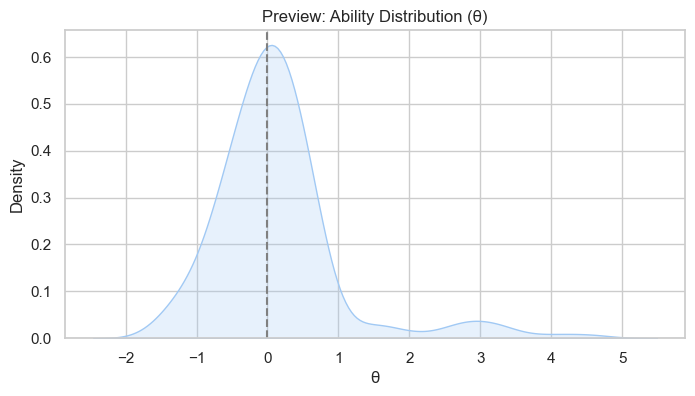

min=-1.51, max=4.54, mean=0.13
Students above 2.5: 10


In [9]:
# --- Ability Construction & Preview ---

# Choose your parameters here
seed = 63111426
n_students = 200


# Main population (right-skewed Beta distribution)
beta_a = 7      # Shape parameter α: higher values push mass toward the right (more good students)
beta_b = 2      # Shape parameter β: lower values keep the distribution skewed (few low-ability students)
scale = 4       # Stretch factor: controls the overall width of the ability range
shift = -3.2      # Shift factor: moves the center of the distribution left/right on the θ scale

# Elite tail (small group of very strong students)
elite_mean = 2.5       # Average ability level of elite students (controls how "excellent" they are)
elite_sd = 1            # Spread of elite abilities (tight cluster vs. more variation)
elite_fraction = 0.1  # Proportion of students drawn from the elite tail (e.g., 7% very strong students)


# Generate
rng = np.random.default_rng(seed)

theta_main = rng.beta(beta_a, beta_b, size=n_students) * scale + shift
theta_elite = rng.normal(loc=elite_mean, scale=elite_sd, size=n_students)
mix = rng.random(size=n_students) < elite_fraction

theta_preview = np.where(mix, theta_elite, theta_main)

# Plot
plt.figure(figsize=(8, 4))
sns.kdeplot(theta_preview, fill=True,)
plt.axvline(0, linestyle="--", color="gray")
plt.title("Preview: Ability Distribution (θ)")
plt.xlabel("θ")
plt.ylabel("Density")
plt.show()

# Summary
print(f"min={theta_preview.min():.2f}, max={theta_preview.max():.2f}, mean={theta_preview.mean():.2f}")
print(f"Students above 2.5: {(theta_preview > 2.5).sum()}")

## Step 2 — Run the Simulation

If you're happy with the θ distribution above, pass `theta_preview` into the
simulation via `SimulationConfig(theta=theta_preview)`.

If not, go back to Step 1, adjust the parameters, and preview again.


In [10]:
# Run the simulation
config = SimulationConfig(
    seed= seed,
    n_items=n_items,
    n_students=n_students,
    output_dir="../data/simulation_results",
    item_type_dist={
        "regular_clean": regular_clean,
        "misleading":misleading,
        "diluted": diluted
    },
    theta=theta_preview
)

results = run_simulation(config)

# Display sample of results
print("\nSample of generated data:")
print("\nAnswer matrix (first 5 students, first 5 items):")
display(results["answer_matrix"].iloc[:5, :5])

print("\nItem metadata (first 5 items):")
display(results["item_metadata"].head())

print("\nTest-taker scores (first 5 students):")
display(results["testtakers"][["theta_true", "carelessness", "guessiness", "score"]].head())

Generating test items...
Simulating responses for 200 students...
Saving results to ..\data\simulation_results...

Sample of generated data:

Answer matrix (first 5 students, first 5 items):


,item1,item2,item3,item4,item5
0,A,D,C,C,D
1,C,C,A,D,C
2,A,D,D,B,A
3,C,D,D,A,B
4,A,C,A,A,B



Item metadata (first 5 items):


,item,item_type,num_options,correct_answer,a_param,b_param,slip,distractors,distractor_weights
0,item1,regular_clean,4,A,1.003326,0.889566,0.019005,"[B, C, D]","{'B': 0.45, 'C': 0.3, 'D': 0.25000000000000006}"
1,item2,regular_clean,5,D,1.448345,-0.810366,0.004695,"[A, B, C, E]","{'A': 0.45, 'B': 0.3, 'C': 0.12500000000000003..."
2,item3,regular_clean,5,D,1.651941,-0.140658,0.021120,"[A, B, C, E]","{'A': 0.45, 'B': 0.3, 'C': 0.12500000000000003..."
3,item4,regular,5,A,0.937108,1.549212,0.107733,"[B, C, D, E]","{'B': 0.45, 'C': 0.3, 'D': 0.12500000000000003..."
4,item5,misleading,4,D,0.892433,0.376604,0.083355,"[A, B, C]","{'A': 0.65625, 'B': 0.18749999999999997, 'C': ..."



Test-taker scores (first 5 students):


,theta_true,carelessness,guessiness,score
0,0.681552,0.011885,0.098792,57.0
1,-0.497513,0.001733,0.019074,42.0
2,0.230947,0.013996,0.160011,55.0
3,-0.161982,0.015904,0.116435,50.0
4,-0.170919,0.012016,0.005031,46.0


In [11]:
def print_summary_statistics(results: SimulationResults) -> None:
    """Print summary statistics of the simulation results."""
    testtakers = results["testtakers"]
    item_metadata = results["item_metadata"]
    
    print("=== Test-Taker Summary ===")
    print(f"Number of students: {len(testtakers)}")
    print(f"Mean score (%): {testtakers['score_pct'].mean():.1f} ± {testtakers['score_pct'].std():.1f}")
    print(f"Score range (%): {testtakers['score_pct'].min()} - {testtakers['score_pct'].max()}")
    print(f"Mean ability (theta): {testtakers['theta_true'].mean():.3f} ± {testtakers['theta_true'].std():.3f}")
    
    print("\n=== Item Analysis ===")
    print(f"Number of items: {len(item_metadata)}")
    print(f"Mean difficulty (b): {item_metadata['b_param'].mean():.3f} ± {item_metadata['b_param'].std():.3f}")
    print(f"Mean discrimination (a): {item_metadata['a_param'].mean():.3f} ± {item_metadata['a_param'].std():.3f}")
    print("\nItem Type Distribution:")
    print(item_metadata["item_type"].value_counts().sort_index())
    
    # Calculate item-total correlations
    item_scores = results["scored_responses"].drop(columns=["score", "score_pct"])
    total_scores = results["scored_responses"]["score"]
    item_total_corrs = item_scores.corrwith(total_scores)
    
    print(f"\nMean item-total correlation: {item_total_corrs.mean():.3f}")

print_summary_statistics(results)

=== Test-Taker Summary ===
Number of students: 200
Mean score (%): 64.4 ± 11.9
Score range (%): 33.75 - 96.25
Mean ability (theta): 0.130 ± 0.912

=== Item Analysis ===
Number of items: 80
Mean difficulty (b): -0.706 ± 1.047
Mean discrimination (a): 1.178 ± 0.362

Item Type Distribution:
item_type
diluted           8
misleading        8
regular          40
regular_clean    24
Name: count, dtype: int64

Mean item-total correlation: 0.261


In [12]:
def plot_item_type_distribution(item_metadata):
    """Plot distribution of item types."""
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(
        data=item_metadata,
        x="item_type",
        hue="item_type",
        legend=False,
        order=list(item_type_colors.keys()),
        palette=item_type_colors,
    )
    ax.set_title("Distribution of Item Types")
    ax.set_xlabel("Item Type")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_answer_options(item_metadata):
    """Plot answer options and correct answers."""
    if "num_options" not in item_metadata.columns:
        item_metadata = item_metadata.copy()
        item_metadata["num_options"] = item_metadata["distractors"].apply(len) + 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(
        data=item_metadata,
        x="num_options",
        color="#dad7cd",
        ax=axes[0],
    )
    axes[0].set_title("Number of Answer Options by Item\n(Including Correct Answer)")
    axes[0].set_xlabel("Number of Answer Options")
    axes[0].set_ylabel("Count")
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    sns.countplot(
        data=item_metadata,
        x="correct_answer",
        color="#ede0bf",
        ax=axes[1],
        order=["A", "B", "C", "D", "E"],
    )
    axes[1].set_title("Distribution of Correct Answers")
    axes[1].set_xlabel("Correct Answer Option")
    axes[1].set_ylabel("Count")
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_item_parameters_scatter(item_metadata):
    """Scatter plot of item parameters."""
    plt.figure(figsize=(8, 4))
    ax = sns.scatterplot(
        data=item_metadata,
        x="b_param",
        y="a_param",
        hue="item_type",
        palette=item_type_colors,
        s=40,
    )

    ax.set_title("Distribution of Item Parameters (a vs b) by Item Type")
    ax.set_xlabel("Difficulty (b)")
    ax.set_ylabel("Discrimination (a)")

    ax.legend(title="Item Type", bbox_to_anchor=(1.05, 1), loc="upper left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_parameter_distributions(item_metadata):
    """Plot distributions of item parameters."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    sns.kdeplot(
        data=item_metadata,
        x="b_param",
        hue="item_type",
        fill=True,
        alpha=0.25,
        common_norm=False, 
        palette=item_type_colors,
        ax=axes[0],
        
    )
    axes[0].set_title("Difficulty (b)")
    axes[0].set_xlabel("b")

    sns.kdeplot(
        data=item_metadata,
        x="a_param",
        hue="item_type",
        fill=True,
        alpha=0.25,
        palette=item_type_colors,
        ax=axes[1],
    )
    axes[1].set_title("Discrimination (a)")
    axes[1].set_xlabel("a")

    plt.tight_layout()
    plt.show()


def plot_slip_distribution(item_metadata):
    """Plot slip parameter distribution by item type."""
    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(
        data=item_metadata,
        x="item_type",
        y="slip",
        hue="item_type",
        legend=False,
        linewidth=0.5,
        palette=item_type_colors,
    )

    ax.set_title("Slip Distribution by Item Type")
    ax.set_xlabel("Item Type")
    ax.set_ylabel("Slip")

    ax.tick_params(axis="x", rotation=20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.show()


def plot_ability_distribution(testtakers):
    """Plot distribution of ability (theta)."""
    plt.figure(figsize=(6, 3))
    sns.kdeplot(testtakers["theta_true"], fill=True, alpha=0.3, color="#3B5070")

    plt.title("Ability Distribution (θ)")
    plt.xlabel("θ")
    plt.axvline(0, color="black", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


def plot_score_analysis(testtakers):
    """Plot score distribution and relationship with ability."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(
        data=testtakers,
        x="score_pct",
        kde=True,
        color="#4C72B0",
        ax=axes[0],
    )

    mean_val = testtakers["score_pct"].mean()
    median_val = testtakers["score_pct"].median()

    axes[0].axvline(mean_val, color="#D62728", linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.1f}%")
    axes[0].axvline(
        median_val,
        color="#2CA02C",
        linestyle="-.",
        linewidth=1.5,
        label=f"Median = {median_val:.1f}%",
    )

    axes[0].set_title("Score Distribution")
    axes[0].set_xlabel("Total Score (%)")
    axes[0].set_ylabel("Count")
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)
    axes[0].legend()

    sns.scatterplot(
        data=testtakers,
        x="theta_true",
        y="score_pct",
        s=40,
        alpha=0.6,
        color="#4C72B0",
        ax=axes[1],
    )
    axes[1].set_title("Total Score (%) vs Ability (θ)")
    axes[1].set_xlabel("Ability (θ)")
    axes[1].set_ylabel("Total Score (%)")
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

Generating visualizations...

1. Item Type Distribution


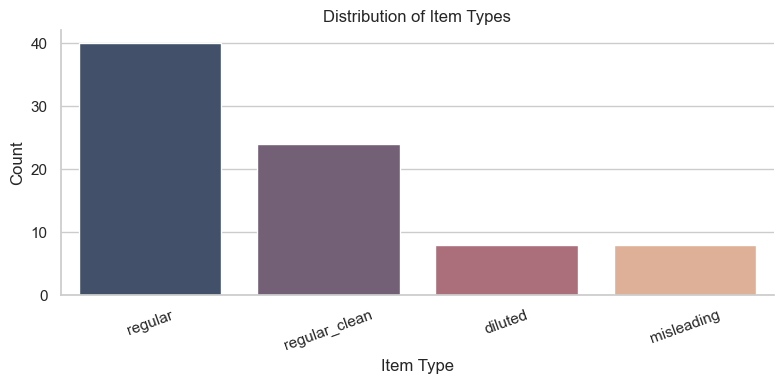


2. Answer Options Analysis


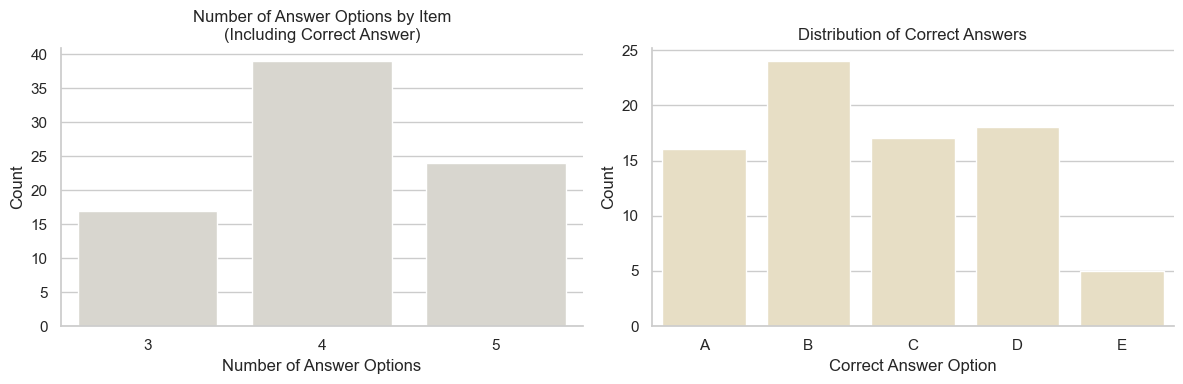


3. Item Parameters Scatter Plot


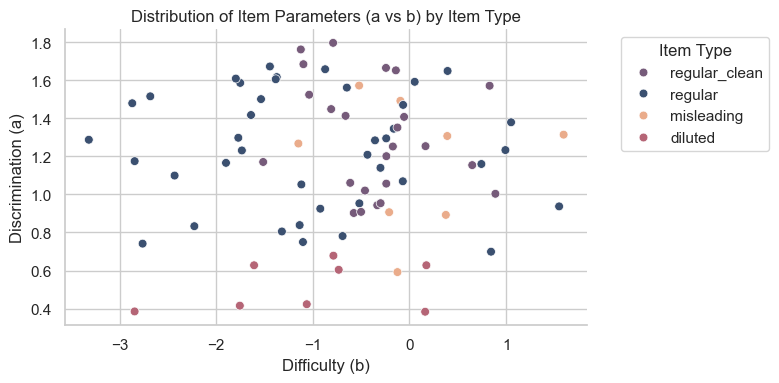


4. Parameter Distributions


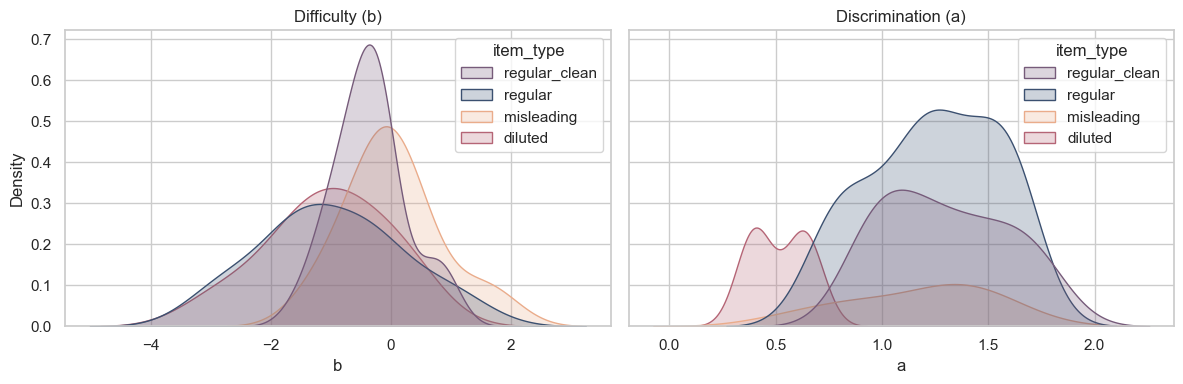


5. Slip Parameter Distribution


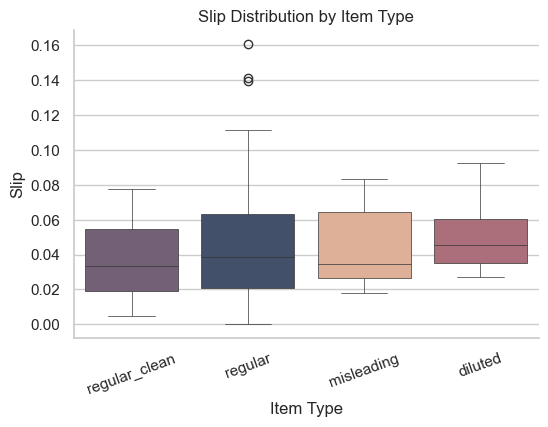


6. Ability Distribution


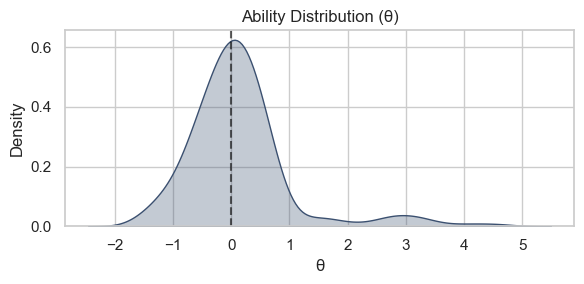


7. Score Analysis


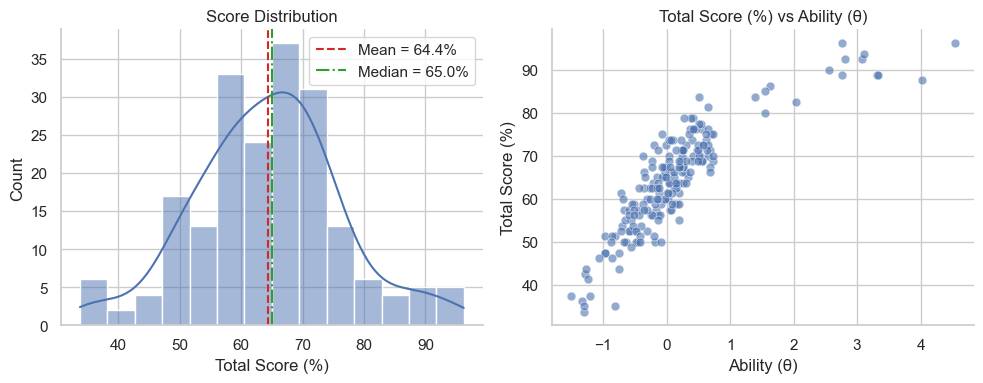


Visualization complete!


In [13]:
item_metadata = results["item_metadata"]
testtakers = results["testtakers"]

# Generate all visualizations
print("Generating visualizations...\n")

print("1. Item Type Distribution")
plot_item_type_distribution(item_metadata)

print("\n2. Answer Options Analysis")
plot_answer_options(item_metadata)

print("\n3. Item Parameters Scatter Plot")
plot_item_parameters_scatter(item_metadata)

print("\n4. Parameter Distributions")
plot_parameter_distributions(item_metadata)

print("\n5. Slip Parameter Distribution")
plot_slip_distribution(item_metadata)

print("\n6. Ability Distribution")
plot_ability_distribution(testtakers)

print("\n7. Score Analysis")
plot_score_analysis(testtakers)

print("\nVisualization complete!")

In [14]:
results['answer_matrix']

,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,item11,item12,item13,item14,item15,item16,item17,item18,item19,item20,item21,item22,item23,item24,item25,item26,item27,item28,item29,item30,item31,item32,item33,item34,item35,item36,item37,item38,item39,item40,item41,item42,item43,item44,item45,item46,item47,item48,item49,item50,item51,item52,item53,item54,item55,item56,item57,item58,item59,item60,item61,item62,item63,item64,item65,item66,item67,item68,item69,item70,item71,item72,item73,item74,item75,item76,item77,item78,item79,item80
0,A,D,C,C,D,C,A,B,B,B,C,C,C,C,D,B,B,B,C,B,C,B,B,C,B,B,E,C,C,A,A,C,B,B,D,C,C,A,A,D,B,D,A,B,A,A,C,C,D,D,C,D,D,C,C,A,C,B,A,A,B,C,C,D,B,C,D,B,B,A,B,C,C,B,C,D,A,C,C,C
1,C,C,A,D,C,C,C,D,B,D,C,B,C,B,D,C,B,D,C,D,B,C,B,B,D,B,C,D,D,D,A,A,B,C,D,C,B,A,A,D,B,D,A,B,C,A,D,D,D,D,A,B,D,A,B,A,C,B,A,A,A,E,B,A,C,B,D,B,B,C,B,B,C,C,E,C,A,C,B,B
2,A,D,D,B,A,A,A,B,B,D,C,C,C,C,D,B,D,C,B,D,C,B,D,B,D,B,C,C,C,A,C,D,B,B,D,B,C,A,A,D,B,B,A,B,C,A,D,C,A,C,D,C,D,C,C,A,C,C,A,A,B,E,C,D,B,B,C,A,D,A,B,C,E,B,E,C,A,C,C,B
3,C,D,D,A,B,A,A,B,C,B,B,B,C,B,D,C,D,B,B,B,B,B,D,B,D,B,D,C,C,E,C,C,B,B,D,C,C,C,A,D,B,D,A,B,A,C,B,C,D,C,C,B,C,E,A,C,C,B,A,D,D,E,C,D,C,B,B,B,B,C,B,C,C,B,C,C,B,C,C,B
4,A,C,A,A,B,C,C,B,B,B,C,B,C,B,D,B,B,C,B,C,B,B,B,C,D,B,C,C,B,D,B,C,B,B,D,C,C,C,C,C,C,D,A,B,A,A,D,A,D,C,A,B,D,C,A,C,A,B,A,A,B,C,A,D,C,B,D,B,B,A,B,B,D,B,E,B,A,C,A,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,B,D,C,C,D,C,A,B,B,D,C,B,C,C,B,A,B,B,D,D,B,B,D,C,C,B,C,D,B,D,B,C,B,C,D,B,C,A,C,D,C,D,A,E,A,A,B,C,B,D,A,B,D,E,C,A,C,B,A,A,B,E,C,D,B,B,D,B,B,A,B,B,C,B,B,D,A,C,B,B
196,A,D,D,A,D,A,A,B,D,B,C,B,C,C,D,B,B,B,A,D,B,B,D,C,D,B,E,C,C,A,C,D,B,A,D,C,C,A,A,D,B,D,A,B,C,A,D,C,D,D,A,D,D,E,B,A,C,B,A,A,B,E,B,D,B,B,B,B,C,A,B,C,E,B,E,C,A,C,C,B
197,C,D,D,D,D,C,D,B,D,B,C,B,B,C,D,C,B,C,C,B,B,B,D,C,A,B,E,B,C,C,B,C,B,B,D,C,C,A,C,C,B,D,A,B,A,A,B,C,D,D,A,D,D,D,A,C,C,B,A,A,D,E,C,C,C,B,D,B,B,A,B,C,E,D,E,C,D,C,D,B
198,C,A,D,D,D,A,A,B,D,E,C,B,B,A,D,A,B,C,B,C,B,B,D,B,A,B,E,C,C,C,A,C,B,C,D,C,C,C,B,D,C,D,A,B,B,C,A,C,C,B,A,B,D,C,B,C,C,B,A,A,C,E,B,D,C,B,D,C,D,B,B,B,C,C,E,C,C,A,C,B
